Considering for sample 50 videos from the dataset

Testing the frame number match. To check if the frame number starts with 0 or 1. 

Testing video: 0X1A3D565B371DC573.avi
Frames from CSV: [np.int64(152), np.int64(176)]
Total frames in video: 327
✅ Matched frame: 152


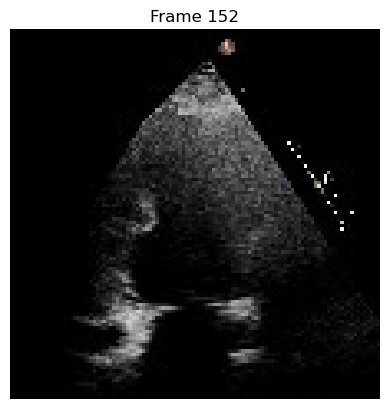

✅ Matched frame: 176


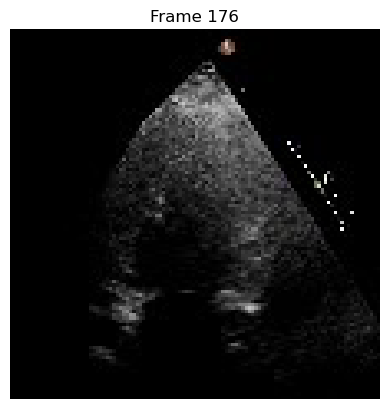

In [ ]:
import cv2
import pandas as pd
import numpy as np
import os

csv_path = "VolumeTracings.csv"
df = pd.read_csv(csv_path)

df['Frame'] = df['Frame'].astype(int)
video_list = df['FileName'].unique()[:50]

for video_name in video_list:
    print(f"\nProcessing {video_name}")
    
    video_path = os.path.join("Videos", video_name)
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Failed to open {video_name}")
        continue

    video_df = df[df['FileName'] == video_name]

    gt_frames = sorted(video_df['Frame'].unique())
    print(f"Frames with GT: {gt_frames}")

    base_folder = os.path.join("output", video_name.replace(".avi", ""))
    img_folder = os.path.join(base_folder, "images")
    mask_folder = os.path.join(base_folder, "masks")

    os.makedirs(img_folder, exist_ok=True)
    os.makedirs(mask_folder, exist_ok=True)

    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx in gt_frames:

            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            mask = np.zeros(gray.shape, dtype=np.uint8)

            rows = video_df[video_df['Frame'] == frame_idx]

            h, w = gray.shape

            for _, row in rows.iterrows():
                x1 = int(row['X1'] * w / 100)
                y1 = int(row['Y1'] * h / 100)
                x2 = int(row['X2'] * w / 100)
                y2 = int(row['Y2'] * h / 100)

                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(w, x2), min(h, y2)

                mask[y1:y2, x1:x2] = 255

            print(f"Saved frame {frame_idx}, mask sum: {np.sum(mask)}")

            cv2.imwrite(os.path.join(img_folder, f"frame_{frame_idx}.png"), gray)
            cv2.imwrite(os.path.join(mask_folder, f"frame_{frame_idx}.png"), mask)

        frame_idx += 1

    cap.release()

print("\n Done! All frames processed.")

In [3]:
import cv2
import pandas as pd
import numpy as np
import os

csv_path = "VolumeTracings.csv"
df = pd.read_csv(csv_path)

df['Frame'] = df['Frame'].astype(int)


video_list = df['FileName'].unique()[:50]

for video_name in video_list:
    print(f"\nProcessing {video_name}")
    
    video_path = os.path.join("Videos", video_name)
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Failed to open {video_name}")
        continue

    video_df = df[df['FileName'] == video_name]

    gt_frames = sorted(video_df['Frame'].unique())
    print(f"Frames with GT: {gt_frames}")

    base_folder = os.path.join("output", video_name.replace(".avi", ""))
    img_folder = os.path.join(base_folder, "images")
    mask_folder = os.path.join(base_folder, "masks")

    os.makedirs(img_folder, exist_ok=True)
    os.makedirs(mask_folder, exist_ok=True)

    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx in gt_frames:

            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            mask = np.zeros(gray.shape, dtype=np.uint8)

            rows = video_df[video_df['Frame'] == frame_idx]

            h, w = gray.shape

            for _, row in rows.iterrows():
                x1 = int(row['X1'] * w / 100)
                y1 = int(row['Y1'] * h / 100)
                x2 = int(row['X2'] * w / 100)
                y2 = int(row['Y2'] * h / 100)

        
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(w, x2), min(h, y2)

                mask[y1:y2, x1:x2] = 255

            print(f"Saved frame {frame_idx}, mask sum: {np.sum(mask)}")

            cv2.imwrite(os.path.join(img_folder, f"frame_{frame_idx}.png"), gray)
            cv2.imwrite(os.path.join(mask_folder, f"frame_{frame_idx}.png"), mask)

        frame_idx += 1

    cap.release()

print("\n Done! All frames processed.")


Processing 0X100009310A3BD7FC.avi
Frames with GT: [np.int64(46), np.int64(61)]
Saved frame 46, mask sum: 229500
Saved frame 61, mask sum: 87465

Processing 0X1002E8FBACD08477.avi
Frames with GT: [np.int64(3), np.int64(18)]
Saved frame 3, mask sum: 308550
Saved frame 18, mask sum: 198645

Processing 0X1005D03EED19C65B.avi
Frames with GT: [np.int64(24), np.int64(35)]
Saved frame 24, mask sum: 212415
Saved frame 35, mask sum: 135660

Processing 0X10075961BC11C88E.avi
Frames with GT: [np.int64(91), np.int64(108)]
Saved frame 91, mask sum: 128520
Saved frame 108, mask sum: 112455

Processing 0X10094BA0A028EAC3.avi
Frames with GT: [np.int64(137), np.int64(156)]
Saved frame 137, mask sum: 54315
Saved frame 156, mask sum: 96390

Processing 0X100CF05D141FF143.avi
Frames with GT: [np.int64(132), np.int64(148)]
Saved frame 132, mask sum: 293760
Saved frame 148, mask sum: 165240

Processing 0X100E3B8D3280BEC5.avi
Frames with GT: [np.int64(25), np.int64(38)]
Saved frame 25, mask sum: 289170
Saved 